# Prologue — Exploratory Data Analysis

Produce empirical evidence about VisDrone2019-DET to motivate the research question.

**Objectives:**
- Bounding box area distribution per class
- Fraction of instances in COCO scale bands (small / medium / large)
- Class imbalance analysis
- Aspect ratio distribution per class
- Sample grid of representative images
- Altitude vs instance density correlation
- Letterboxing effect visualization
- Theory connections: CNN downsampling, mAP, class imbalance

**Output figures saved to `results/figures/`**


In [1]:
import sys, os, json, math
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import PercentFormatter
from PIL import Image
from tqdm.notebook import tqdm

# Project root
root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from src.env import get_paths, get_device, seed_everything
seed_everything(42)

paths = get_paths()
device = get_device()

# Load setup report for dataset info
setup_report_path = root / "results" / "setup_report.json"
if setup_report_path.exists():
    with open(setup_report_path) as f:
        setup = json.load(f)
    print(f"[OK] Setup report loaded: {setup['timestamp']}")
else:
    print("[WARN] setup_report.json not found. Run 00_setup_environment.ipynb first.")

# Constants
VISDRONE_CLASSES = [
    "pedestrian", "people", "bicycle", "car", "van",
    "truck", "tricycle", "awning-tricycle", "bus", "motor",
]
CLASS_COLORS = plt.cm.tab10(np.linspace(0, 1, 10))
COCO_SMALL_MAX = 32 * 32
COCO_MEDIUM_MAX = 96 * 96

# paths["data"] resolves to project/data/VisDrone2019-DET/
target_dir = paths["data"]
figures_dir = root / "results" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Device: {device}")
print(f"Data: {target_dir}")
print(f"  exists: {target_dir.exists()}")
print(f"  train ann: {(target_dir / 'annotations' / 'train').exists()}")
print(f"Figures: {figures_dir}")


[OK] Setup report loaded: 2026-06-16T18:26:37.744230
Device: mps
Data: /Users/davide/Desktop/Universita/AI/CV_DL/project/data/VisDrone2019-DET
  exists: True
  train ann: True
Figures: /Users/davide/Desktop/Universita/AI/CV_DL/project/results/figures


In [2]:
"""Load all YOLO+ annotations and image metadata into DataFrames."""

SPLITS = {"train": "train", "val": "val", "test-dev": "test-dev"}
records = []

for split_key, split_name in SPLITS.items():
    ann_dir = target_dir / "annotations" / split_name
    if not ann_dir.exists():
        print(f"[SKIP] {split_name}: annotations not found")
        continue

    ann_files = sorted(ann_dir.glob("*.txt"))
    for ann_file in tqdm(ann_files, desc=f"Loading {split_name}"):
        with open(ann_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id = int(float(parts[0]))
                cx = float(parts[1])
                cy = float(parts[2])
                w = float(parts[3])
                h = float(parts[4])
                # Area in normalized coordinates
                area_norm = w * h
                # Aspect ratio
                aspect = w / h if h > 0 else 0
                # Occlusion / truncation (if available)
                occlusion = int(parts[5]) if len(parts) >= 7 else -1
                truncation = int(parts[6]) if len(parts) >= 7 else -1

                records.append({
                    "split": split_key,
                    "file": ann_file.name,
                    "class_id": cls_id,
                    "class_name": VISDRONE_CLASSES[cls_id],
                    "cx": cx, "cy": cy,
                    "w": w, "h": h,
                    "area_norm": area_norm,
                    "aspect_ratio": aspect,
                    "occlusion": occlusion,
                    "truncation": truncation,
                })

df = pd.DataFrame(records)
n_total = len(df)
n_train = len(df[df["split"] == "train"])
n_val = len(df[df["split"] == "val"])
n_test = len(df[df["split"] == "test-dev"])

print(f"\nTotal annotations loaded: {n_total:,}")
print(f"  Train:    {n_train:>8,}")
print(f"  Val:      {n_val:>8,}")
print(f"  Test-dev: {n_test:>8,}")
print(f"\nColumns: {list(df.columns)}")


Loading train:   0%|          | 0/6471 [00:00<?, ?it/s]

Loading val:   0%|          | 0/548 [00:00<?, ?it/s]

Loading test-dev:   0%|          | 0/1610 [00:00<?, ?it/s]


Total annotations loaded: 457,066
  Train:     343,205
  Val:        38,759
  Test-dev:   75,102

Columns: ['split', 'file', 'class_id', 'class_name', 'cx', 'cy', 'w', 'h', 'area_norm', 'aspect_ratio', 'occlusion', 'truncation']


## 1. Bounding Box Area Distribution

The normalized area (w × h) is not directly comparable across images of different resolutions.
We compute **absolute pixel area** using the original image resolution (~2000×1500 px).

For annotations at original resolution: `area_px = area_norm * (img_width * img_height)`.
Since VisDrone images are ~2000×1500, we approximate: `area_px ≈ area_norm * 3e6`.


Mean image size from sample: 1308 x 736 (1.0 MP)

Per-class bounding box area (pixels):


,count,mean,std,min,25%,50%,75%,max
class_name,,,,,,,,
awning-tricycle,4377.0,1692.615127,2902.284551,7.456920,346.331825,831.689901,1905.179961,60315.743854
bicycle,13069.0,640.543080,998.459770,3.849925,153.524648,344.209102,748.130234,23951.592638
bus,9117.0,4932.507801,9802.207931,7.857514,729.255511,2015.087698,5236.948893,212308.526864
car,187005.0,1936.096922,3749.933500,0.000000,265.605862,729.282379,2045.610432,328771.851985
motor,40378.0,583.188623,914.312432,3.207549,148.302796,332.993722,683.153653,54356.169022
pedestrian,109187.0,443.150838,833.424774,3.928986,84.687768,204.140688,479.139914,53774.175467
people,38560.0,360.370429,785.999752,1.398549,78.564599,178.206089,392.811538,47574.578524
tricycle,6387.0,1596.274685,2446.778249,3.849925,337.252799,849.844639,1875.186600,46672.579308
truck,16284.0,4386.180431,10434.364179,5.892104,549.936725,1526.593254,4321.438273,293463.170321


/var/folders/gl/tjkz5rss25z3v_6dz_r7641c0000gn/T/ipykernel_2008/2536589896.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=classes_sorted, vert=True, patch_artist=True,


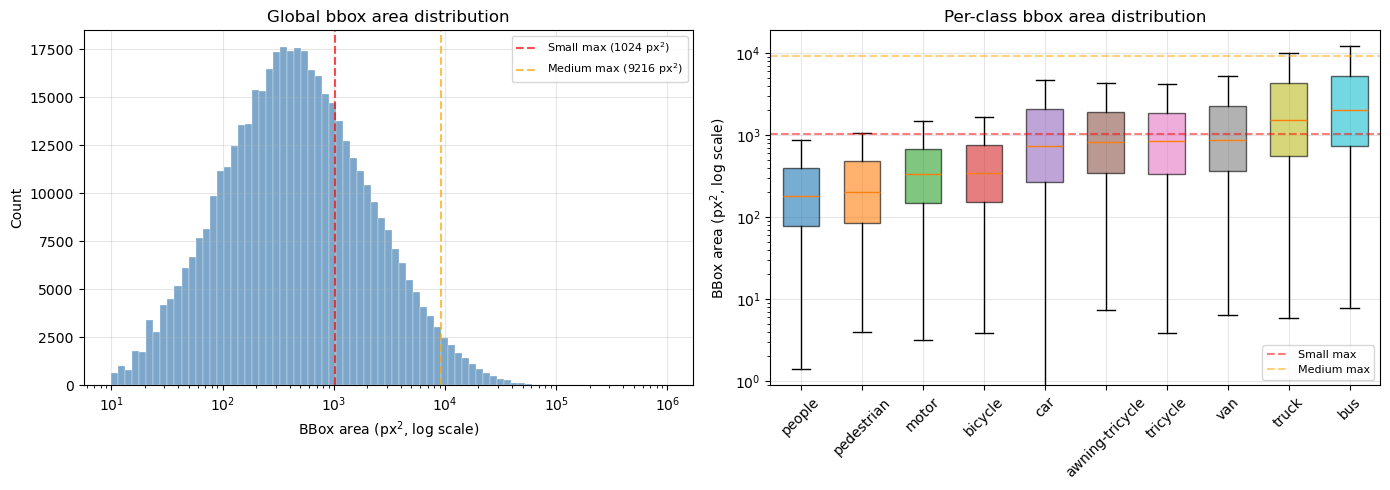

[Figure saved] /Users/davide/Desktop/Universita/AI/CV_DL/project/results/figures/eda_scale_distribution.png


In [3]:
# Estimate absolute pixel area using a sample of actual image sizes
from PIL import Image

# Sample some images to get typical resolution
sample_imgs = list((target_dir / "images" / "val").glob("*.jpg"))[:20]
img_sizes = []
for impath in sample_imgs:
    with Image.open(impath) as img:
        img_sizes.append(img.size)

mean_w = np.mean([s[0] for s in img_sizes])
mean_h = np.mean([s[1] for s in img_sizes])
print(f"Mean image size from sample: {mean_w:.0f} x {mean_h:.0f} ({mean_w*mean_h/1e6:.1f} MP)")

# Estimate pixel area for all boxes
scale_factor = mean_w * mean_h
df["area_px"] = df["area_norm"] * scale_factor

# Per-class area stats
print("\nPer-class bounding box area (pixels):")
class_area_stats = df.groupby("class_name")["area_px"].describe(percentiles=[.25, .5, .75])
display(class_area_stats)

# Global cumulative distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: global histogram
ax = axes[0]
bin_edges = np.logspace(np.log10(10), np.log10(scale_factor), 80)
ax.hist(df["area_px"], bins=bin_edges, color="steelblue", alpha=0.7, edgecolor="white", linewidth=0.3)
ax.set_xscale("log")
ax.set_xlabel("BBox area (px$^2$, log scale)")
ax.set_ylabel("Count")
ax.set_title("Global bbox area distribution")
ax.axvline(COCO_SMALL_MAX, color="red", linestyle="--", alpha=0.7, label=f"Small max ({COCO_SMALL_MAX} px$^2$)")
ax.axvline(COCO_MEDIUM_MAX, color="orange", linestyle="--", alpha=0.7, label=f"Medium max ({COCO_MEDIUM_MAX} px$^2$)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: per-class box plots
ax = axes[1]
classes_sorted = df.groupby("class_name")["area_px"].median().sort_values().index
bp_data = [df[df["class_name"] == c]["area_px"].values for c in classes_sorted]
bp = ax.boxplot(bp_data, labels=classes_sorted, vert=True, patch_artist=True,
                showfliers=False, widths=0.6)
for patch, color in zip(bp["boxes"], [CLASS_COLORS[i] for i in range(10)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_yscale("log")
ax.set_ylabel("BBox area (px$^2$, log scale)")
ax.set_title("Per-class bbox area distribution")
ax.tick_params(axis="x", rotation=45)
ax.axhline(COCO_SMALL_MAX, color="red", linestyle="--", alpha=0.5, label=f"Small max")
ax.axhline(COCO_MEDIUM_MAX, color="orange", linestyle="--", alpha=0.5, label=f"Medium max")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / "eda_scale_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[Figure saved] {figures_dir / 'eda_scale_distribution.png'}")


## 2. COCO Scale Bands

COCO convention: small (area < 32² px), medium (32²–96² px), large (> 96² px).
Critical for research question: if >50% instances are small, the dataset is fundamentally small-object dominated.


COCO scale distribution (all splits):
  small   :  322,558 (70.6%)
  medium  :  122,711 (26.8%)
  large   :   11,797 (2.6%)

Per-class scale breakdown (% within each class):


scale,large,medium,small
class_name,,,
awning-tricycle,2.1,41.6,56.2
bicycle,0.2,16.8,83.0
bus,13.1,54.5,32.4
car,3.7,37.4,58.9
motor,0.1,14.6,85.3
pedestrian,0.1,10.1,89.8
people,0.1,6.6,93.3
tricycle,1.6,42.1,56.3
truck,11.1,49.2,39.7


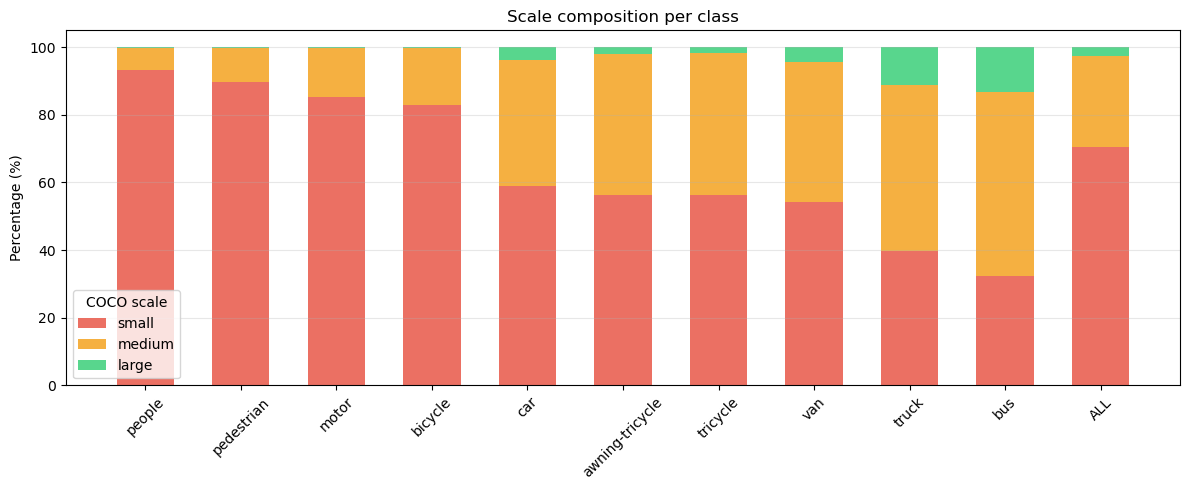

In [4]:
def scale_category(area_px):
    if area_px < COCO_SMALL_MAX:
        return "small"
    elif area_px < COCO_MEDIUM_MAX:
        return "medium"
    else:
        return "large"

df["scale"] = df["area_px"].apply(scale_category)

# Overall distribution
scale_counts = df["scale"].value_counts()
scale_pcts = df["scale"].value_counts(normalize=True) * 100

print("COCO scale distribution (all splits):")
for scale in ["small", "medium", "large"]:
    print(f"  {scale:8s}: {scale_counts.get(scale, 0):>8,} ({scale_pcts.get(scale, 0):.1f}%)")

# Per-class scale breakdown
print("\nPer-class scale breakdown (% within each class):")
scale_per_class = df.groupby("class_name")["scale"].value_counts(normalize=True).unstack() * 100
display(scale_per_class.round(1))

# Figure: stacked bar per class
fig, ax = plt.subplots(figsize=(12, 5))
classes_sorted = df.groupby("class_name")["area_px"].median().sort_values().index
bottom = np.zeros(len(classes_sorted))
scale_colors = {"small": "#e74c3c", "medium": "#f39c12", "large": "#2ecc71"}

for scale in ["small", "medium", "large"]:
    vals = []
    for c in classes_sorted:
        sub = df[df["class_name"] == c]
        vals.append(len(sub[sub["scale"] == scale]) / len(sub) * 100)
    ax.bar(classes_sorted, vals, bottom=bottom, label=scale,
           color=scale_colors[scale], alpha=0.8, width=0.6)
    bottom += vals

ax.set_ylabel("Percentage (%)")
ax.set_title("Scale composition per class")
ax.legend(title="COCO scale")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)

# Add overall as last bar
overall_vals = [scale_pcts.get(s, 0) for s in ["small", "medium", "large"]]
ax.bar("ALL", overall_vals[0], color=scale_colors["small"], alpha=0.8, width=0.6)
ax.bar("ALL", overall_vals[1], bottom=overall_vals[0], color=scale_colors["medium"], alpha=0.8, width=0.6)
ax.bar("ALL", overall_vals[2], bottom=overall_vals[0]+overall_vals[1], color=scale_colors["large"], alpha=0.8, width=0.6)

plt.tight_layout()
plt.savefig(figures_dir / "eda_scale_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Class Imbalance

Instance count per class. Extreme imbalance impacts training (rare classes may be ignored by the detector).


Class imbalance ratio (max/min): 42.7x
Total instances: 457,066



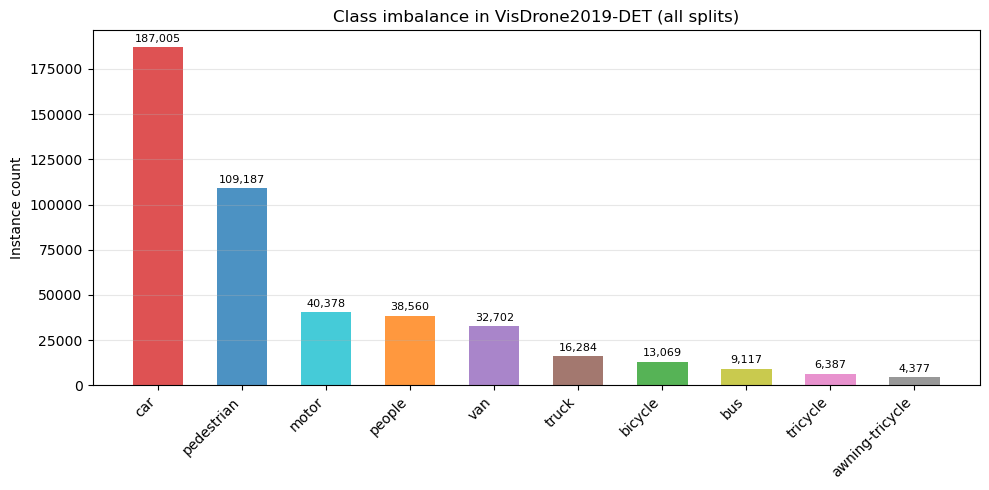

[Figure saved] /Users/davide/Desktop/Universita/AI/CV_DL/project/results/figures/eda_class_imbalance.png

Per-split class counts:


class_name,awning-tricycle,bicycle,bus,car,motor,pedestrian,people,tricycle,truck,van
split,,,,,,,,,,
test-dev,599,1302,2940,28074,5845,21006,6376,530,2659,5771
train,3246,10480,5926,144867,29647,79337,27059,4812,12875,24956
val,532,1287,251,14064,4886,8844,5125,1045,750,1975


In [5]:
class_counts = df.groupby("class_name").size().sort_values(ascending=False)
imbalance_ratio = class_counts.max() / class_counts.min()

print(f"Class imbalance ratio (max/min): {imbalance_ratio:.1f}x")
print(f"Total instances: {len(df):,}\n")

fig, ax = plt.subplots(figsize=(10, 5))
colors = [CLASS_COLORS[VISDRONE_CLASSES.index(c)] for c in class_counts.index]
bars = ax.bar(range(len(class_counts)), class_counts.values, color=colors, alpha=0.8, width=0.6)
ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(class_counts.index, rotation=45, ha="right")
ax.set_ylabel("Instance count")
ax.set_title("Class imbalance in VisDrone2019-DET (all splits)")
ax.grid(True, axis="y", alpha=0.3)

# Add count labels on bars
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(class_counts)*0.01,
            f"{count:,}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(figures_dir / "eda_class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[Figure saved] {figures_dir / 'eda_class_imbalance.png'}")

# Per-split breakdown
print("\nPer-split class counts:")
split_class = df.groupby(["split", "class_name"]).size().unstack()
display(split_class)


## 4. Aspect Ratio Distribution

Aspect ratio (width / height) per class. Important for anchor design in YOLO and RPN.


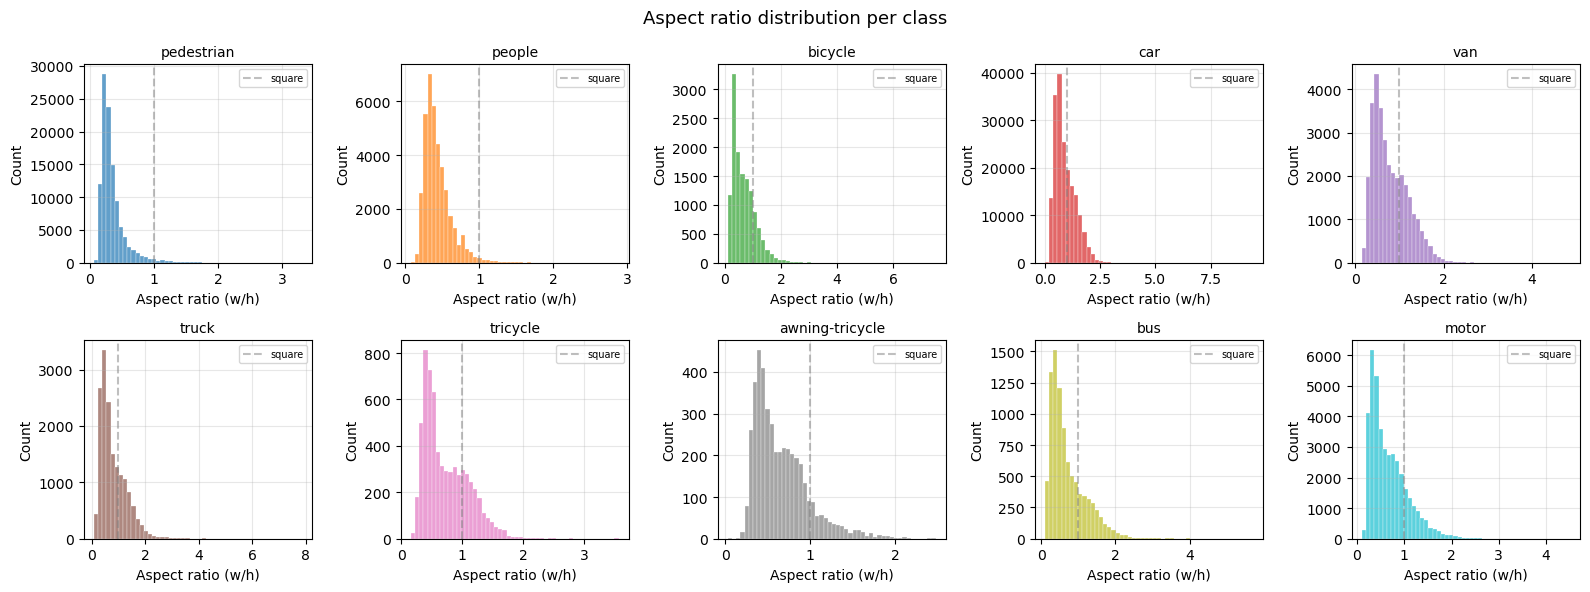

[Figure saved] /Users/davide/Desktop/Universita/AI/CV_DL/project/results/figures/eda_aspect_ratios.png

Aspect ratio stats per class:


,count,mean,std,min,25%,50%,75%,max
class_name,,,,,,,,
awning-tricycle,4377.0,0.658,0.323,0.030,0.415,0.572,0.825,2.479
bicycle,13069.0,0.673,0.413,0.113,0.348,0.563,0.900,7.503
bus,9117.0,0.716,0.485,0.102,0.363,0.557,0.960,5.699
car,187005.0,0.914,0.464,0.000,0.563,0.788,1.208,9.406
motor,40378.0,0.674,0.397,0.106,0.361,0.563,0.889,4.499
pedestrian,109187.0,0.350,0.207,0.063,0.225,0.289,0.399,3.300
people,38560.0,0.437,0.190,0.075,0.308,0.391,0.516,2.882
tricycle,6387.0,0.734,0.363,0.158,0.438,0.625,0.990,3.563
truck,16284.0,0.814,0.498,0.093,0.442,0.657,1.102,7.850


In [6]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()

for i, cls_name in enumerate(VISDRONE_CLASSES):
    ax = axes[i]
    cls_data = df[df["class_name"] == cls_name]["aspect_ratio"].values
    cls_data = cls_data[cls_data < 10]  # clip extreme outliers for visualization
    ax.hist(cls_data, bins=50, color=CLASS_COLORS[i], alpha=0.7, edgecolor="white", linewidth=0.3)
    ax.set_title(cls_name, fontsize=10)
    ax.set_xlabel("Aspect ratio (w/h)")
    ax.set_ylabel("Count")
    ax.axvline(1.0, color="gray", linestyle="--", alpha=0.5, label="square")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Aspect ratio distribution per class", fontsize=13)
plt.tight_layout()
plt.savefig(figures_dir / "eda_aspect_ratios.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[Figure saved] {figures_dir / 'eda_aspect_ratios.png'}")

# Summary stats
print("\nAspect ratio stats per class:")
ar_stats = df.groupby("class_name")["aspect_ratio"].describe(percentiles=[.25, .5, .75])
display(ar_stats.round(3))


## 5. Sample Image Visualization

Show 10 representative images with ground truth bounding boxes:
- 5 dense urban scenes (high pedestrian count)
- 5 sparse scenes (few objects, mostly vehicles)


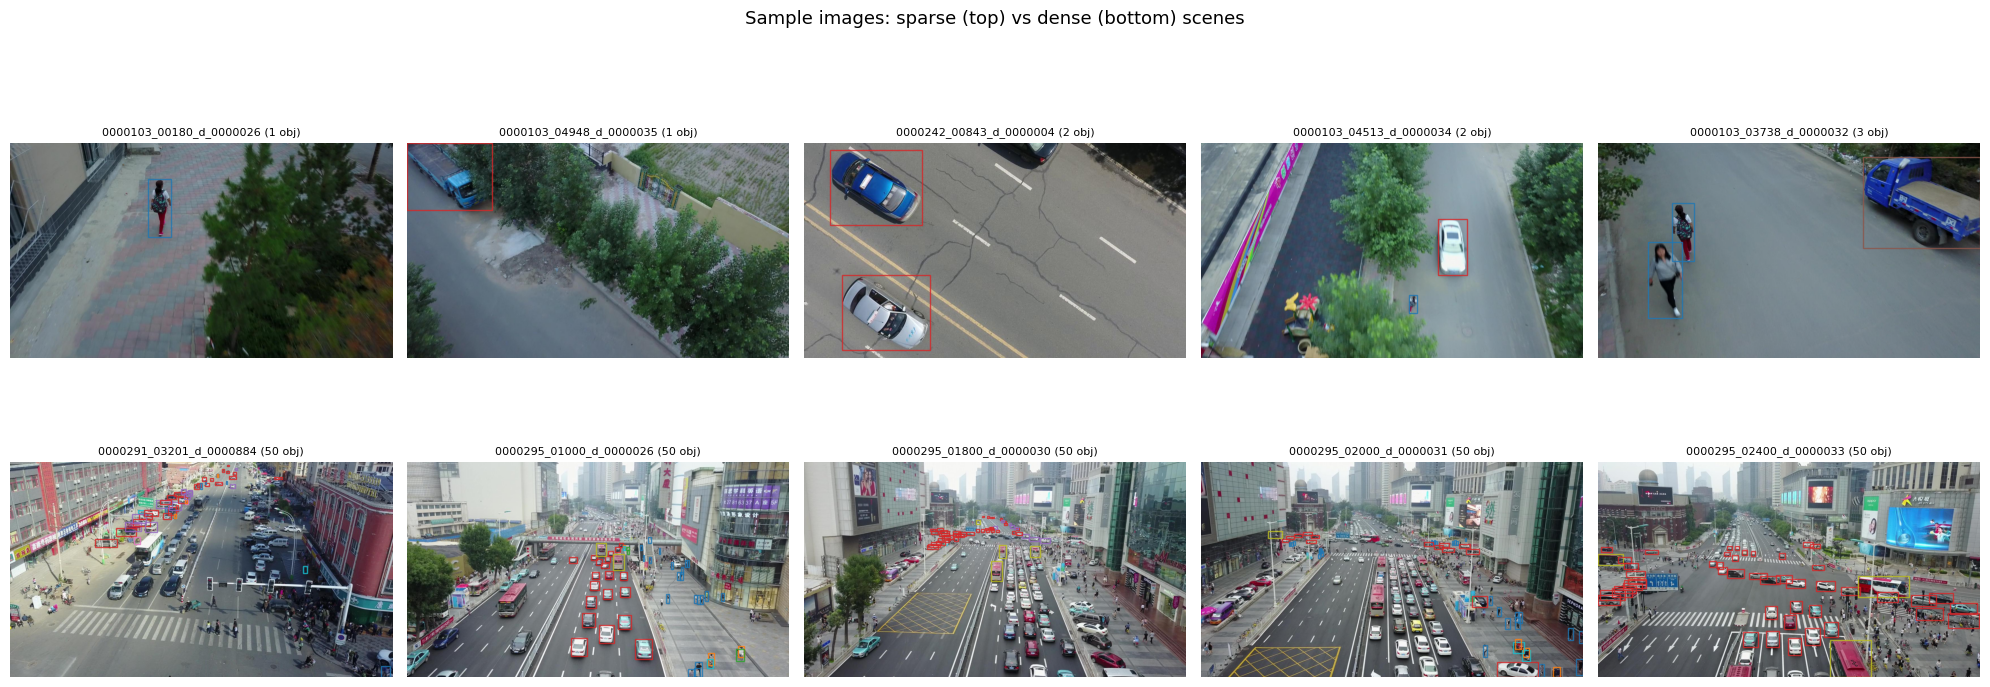

[Figure saved] /Users/davide/Desktop/Universita/AI/CV_DL/project/results/figures/eda_sample_grid.png


In [7]:
def draw_bboxes_on_image(img_path, ann_path, ax, max_boxes=50):
    """Draw YOLO+ bboxes on image."""
    img = Image.open(img_path)
    w_img, h_img = img.size
    ax.imshow(img)
    
    if not ann_path.exists():
        ax.set_title(f"No annotations", fontsize=8)
        return
    
    with open(ann_path) as f:
        lines = f.readlines()[:max_boxes]
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cls_id = int(float(parts[0]))
        cx = float(parts[1]) * w_img
        cy = float(parts[2]) * h_img
        bw = float(parts[3]) * w_img
        bh = float(parts[4]) * h_img
        x1 = cx - bw / 2
        y1 = cy - bh / 2
        
        rect = patches.Rectangle((x1, y1), bw, bh, linewidth=1,
                                  edgecolor=CLASS_COLORS[cls_id], facecolor="none", alpha=0.8)
        ax.add_patch(rect)
    
    ax.set_title(f"{ann_path.stem} ({len(lines)} obj)", fontsize=8)
    ax.axis("off")


# Find dense vs sparse images using annotation count
val_ann_dir = target_dir / "annotations" / "val"
val_img_dir = target_dir / "images" / "val"

ann_counts = []
for ann_file in val_ann_dir.glob("*.txt"):
    with open(ann_file) as f:
        n = sum(1 for line in f if line.strip())
    ann_counts.append((ann_file.stem, n))

ann_counts.sort(key=lambda x: x[1])

# Pick 5 densest and 5 sparsest
sparse_samples = ann_counts[:5]
dense_samples = ann_counts[-5:]
selected = sparse_samples + dense_samples

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, (stem, n_obj) in enumerate(selected):
    img_path = val_img_dir / f"{stem}.jpg"
    ann_path = val_ann_dir / f"{stem}.txt"
    draw_bboxes_on_image(img_path, ann_path, axes[idx])

plt.suptitle("Sample images: sparse (top) vs dense (bottom) scenes", fontsize=13)
plt.tight_layout()
plt.savefig(figures_dir / "eda_sample_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[Figure saved] {figures_dir / 'eda_sample_grid.png'}")


## 6. Altitude vs Instance Density

**Proxy:** median bbox area per image ≈ inverse altitude (smaller objects → higher altitude).
**Density:** number of objects per image.

Motivates the altitude-performance correlation revisited in E4.


Image-level stats (validation set):
  Images: 548
  Median objects/image: 65
  Median area/image: 583 px^2


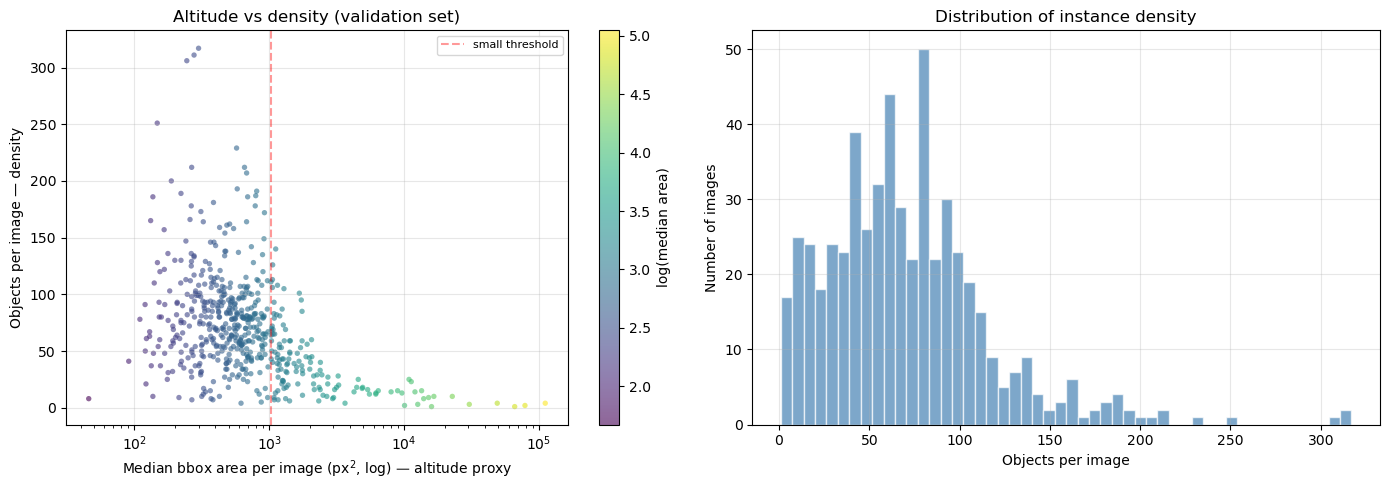

[Figure saved] /Users/davide/Desktop/Universita/AI/CV_DL/project/results/figures/eda_altitude_density_scatter.png


In [8]:
# Per-image stats
img_stats = df[df["split"] == "val"].groupby("file").agg(
    median_area=("area_px", "median"),
    mean_area=("area_px", "mean"),
    n_objects=("area_px", "count"),
    n_classes=("class_id", "nunique"),
).reset_index()

# Altitude proxy: smaller median area = higher altitude
# Density: objects per image
print("Image-level stats (validation set):")
print(f"  Images: {len(img_stats)}")
print(f"  Median objects/image: {img_stats['n_objects'].median():.0f}")
print(f"  Median area/image: {img_stats['median_area'].median():.0f} px^2")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: altitude vs density scatter
ax = axes[0]
sc = ax.scatter(img_stats["median_area"], img_stats["n_objects"],
                c=np.log10(img_stats["median_area"] + 1), cmap="viridis",
                alpha=0.6, s=15, edgecolors="none")
ax.set_xscale("log")
ax.set_xlabel("Median bbox area per image (px$^2$, log) — altitude proxy")
ax.set_ylabel("Objects per image — density")
ax.set_title("Altitude vs density (validation set)")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("log(median area)")
ax.axvline(COCO_SMALL_MAX, color="red", linestyle="--", alpha=0.4, label="small threshold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: histogram of objects per image
ax = axes[1]
ax.hist(img_stats["n_objects"], bins=50, color="steelblue", alpha=0.7, edgecolor="white")
ax.set_xlabel("Objects per image")
ax.set_ylabel("Number of images")
ax.set_title("Distribution of instance density")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / "eda_altitude_density_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[Figure saved] {figures_dir / 'eda_altitude_density_scatter.png'}")


## 7. Letterboxing Effect

When a 2000×1500 px image is resized to 640×640 for YOLO inference, objects are
dramatically downsampled. A 20×20 px pedestrian becomes ~6×6 px in the resized image.

This visualization demonstrates the core challenge: small objects become near-impossible
to detect after aggressive downsampling.


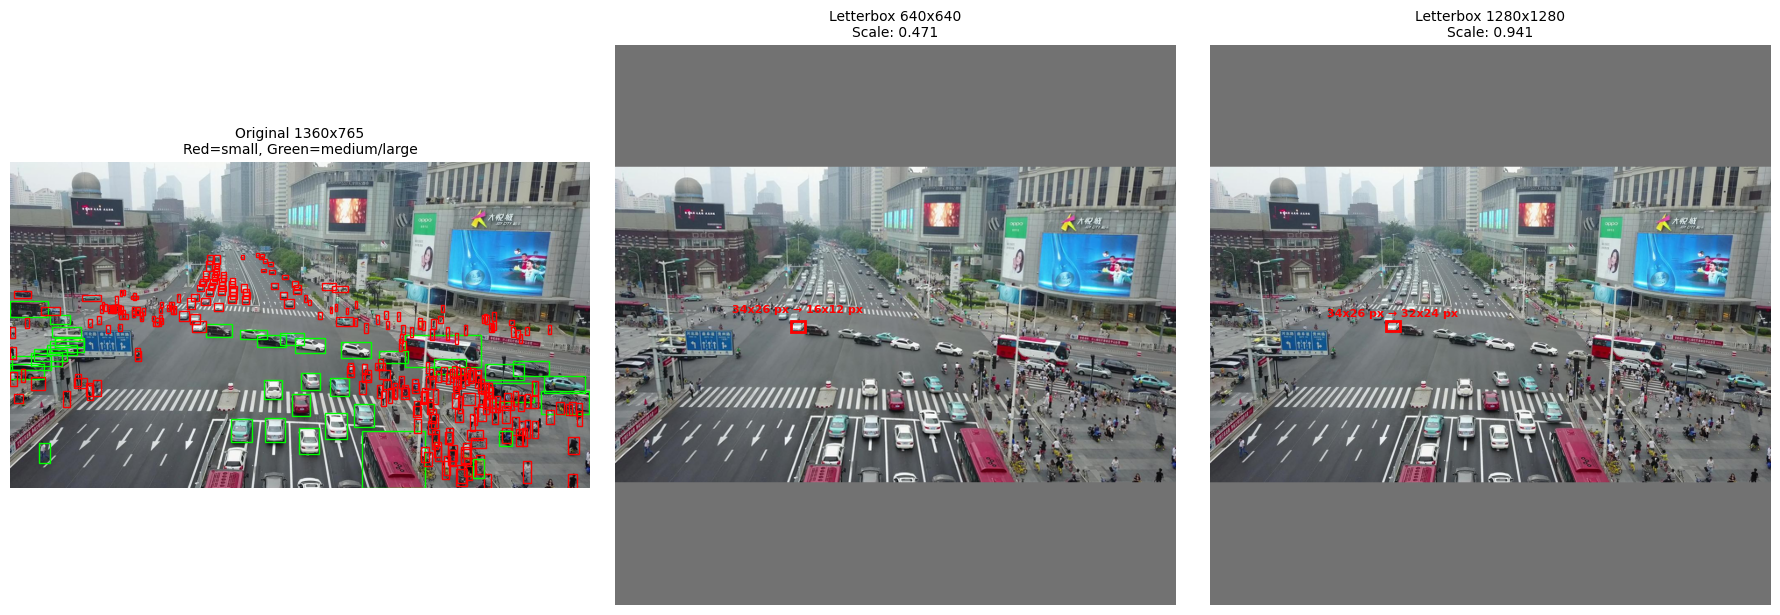

[Figure saved] /Users/davide/Desktop/Universita/AI/CV_DL/project/results/figures/eda_letterboxing.png

Quantitative effect of downsampling on small objects:
  640px input: 20px object → 6.4px (41 px$^2$)
  480px input: 20px object → 4.8px (23 px$^2$)
  320px input: 20px object → 3.2px (10 px$^2$)


In [9]:
# Pick an image with small objects (high annotation count = dense scene)
val_ann_dir = target_dir / "annotations" / "val"
val_img_dir = target_dir / "images" / "val"

# Find an image with many small objects
val_df = df[df["split"] == "val"]
small_val = val_df[val_df["scale"] == "small"]
dense_small = small_val.groupby("file").size().sort_values(ascending=False)
target_file = dense_small.index[0]

img_path = val_img_dir / target_file.replace(".txt", ".jpg")
ann_path = val_ann_dir / target_file

img = Image.open(img_path)
orig_w, orig_h = img.size

# Target sizes for letterboxing
target_sizes = [640, 1280]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original image with small bbox highlighted
ax = axes[0]
ax.imshow(img)
with open(ann_path) as f:
    lines = f.readlines()

small_boxes = []
for line in lines:
    parts = line.strip().split()
    if len(parts) < 5:
        continue
    cls_id = int(float(parts[0]))
    cx = float(parts[1]) * orig_w
    cy = float(parts[2]) * orig_h
    bw = float(parts[3]) * orig_w
    bh = float(parts[4]) * orig_h
    area = bw * bh
    x1 = cx - bw/2
    y1 = cy - bh/2
    color = "red" if area < COCO_SMALL_MAX else "lime"
    rect = patches.Rectangle((x1, y1), bw, bh, linewidth=1, edgecolor=color, facecolor="none")
    ax.add_patch(rect)
    if area < COCO_SMALL_MAX:
        small_boxes.append((x1, y1, bw, bh))

ax.set_title(f"Original {orig_w}x{orig_h}\nRed=small, Green=medium/large", fontsize=10)
ax.axis("off")

# Letterboxed versions
for idx, target_size in enumerate(target_sizes, 1):
    ax = axes[idx]
    # Calculate scale and padding
    scale = min(target_size / orig_w, target_size / orig_h)
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)
    pad_w = (target_size - new_w) // 2
    pad_h = (target_size - new_h) // 2

    img_resized = img.resize((new_w, new_h), Image.LANCZOS)
    letterboxed = Image.new("RGB", (target_size, target_size), (114, 114, 114))
    letterboxed.paste(img_resized, (pad_w, pad_h))

    ax.imshow(letterboxed)

    # Show how a small object shrinks
    if small_boxes:
        sx, sy, sw, sh = small_boxes[0]
        # Project to letterbox coords
        nsx = sx * scale + pad_w
        nsy = sy * scale + pad_h
        nsw = sw * scale
        nsh = sh * scale
        rect = patches.Rectangle((nsx, nsy), nsw, nsh, linewidth=2,
                                  edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.annotate(f"{sw:.0f}x{sh:.0f} px → {nsw:.0f}x{nsh:.0f} px",
                    (nsx + nsw/2, nsy - 10), ha="center", fontsize=8,
                    color="red", fontweight="bold")

    ax.set_title(f"Letterbox {target_size}x{target_size}\nScale: {scale:.3f}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig(figures_dir / "eda_letterboxing.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[Figure saved] {figures_dir / 'eda_letterboxing.png'}")

# Print quantitative effect
print("\nQuantitative effect of downsampling on small objects:")
for target_size in [640, 480, 320]:
    scale = min(target_size / 2000, target_size / 1500)
    px_20 = 20 * scale
    print(f"  {target_size}px input: 20px object → {px_20:.1f}px ({px_20*px_20:.0f} px$^2$)")


## 8. Occlusion & Truncation Analysis

Flags preserved from original VisDrone annotations for E4 error analysis.


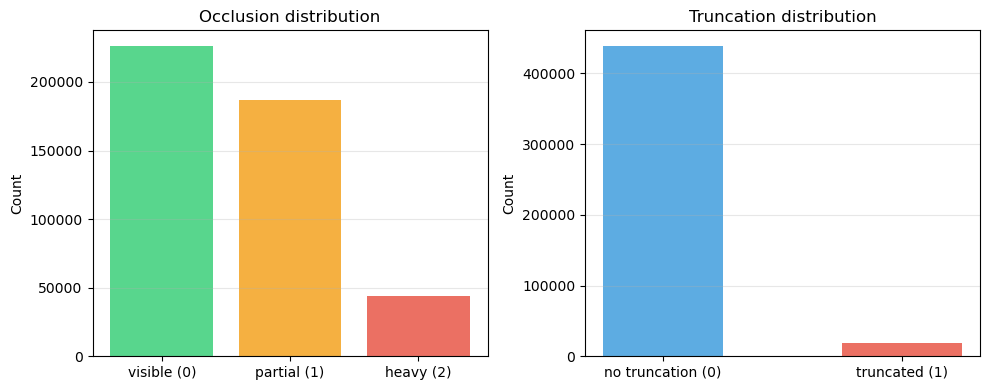

Occlusion:
  0:  226,333 (49.5%)
  1:  187,006 (40.9%)
  2:   43,727 (9.6%)
Truncation:
  0:  438,952 (96.0%)
  1:   18,114 (4.0%)


In [10]:
# Only objects with the flag present (not -1)
has_occ = df[df["occlusion"] >= 0]

if len(has_occ) > 0:
    occ_counts = has_occ["occlusion"].value_counts().sort_index()
    trunc_counts = has_occ["truncation"].value_counts().sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].bar(["visible (0)", "partial (1)", "heavy (2)"], 
                 [occ_counts.get(i, 0) for i in [0, 1, 2]],
                 color=["#2ecc71", "#f39c12", "#e74c3c"], alpha=0.8)
    axes[0].set_title("Occlusion distribution")
    axes[0].set_ylabel("Count")
    axes[0].grid(True, axis="y", alpha=0.3)

    axes[1].bar(["no truncation (0)", "truncated (1)"],
                 [trunc_counts.get(i, 0) for i in [0, 1]],
                 color=["#3498db", "#e74c3c"], alpha=0.8, width=0.5)
    axes[1].set_title("Truncation distribution")
    axes[1].set_ylabel("Count")
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(figures_dir / "eda_occlusion_truncation.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print("Occlusion:")
    for k in [0, 1, 2]:
        print(f"  {k}: {occ_counts.get(k, 0):>8,} ({occ_counts.get(k, 0)/len(has_occ)*100:.1f}%)")
    print("Truncation:")
    for k in [0, 1]:
        print(f"  {k}: {trunc_counts.get(k, 0):>8,} ({trunc_counts.get(k, 0)/len(has_occ)*100:.1f}%)")
else:
    print("[SKIP] Occlusion/truncation not available in annotations.")


## 9. Summary & Key Findings

Aggregate all EDA metrics into a single summary table.


In [11]:
summary = pd.DataFrame({
    "Metric": [
        "Total annotations",
        "Training images",
        "Validation images",
        "Test-dev images",
        "Classes",
        "Class imbalance ratio (max/min)",
        "Small objects (% of total)",
        "Medium objects (% of total)",
        "Large objects (% of total)",
        "Mean objects/image (val)",
        "Median objects/image (val)",
        "Mean image resolution",
        "Annotation format",
    ],
    "Value": [
        f"{len(df):,}",
        "6,471",
        "548",
        "1,610",
        "10",
        f"{imbalance_ratio:.1f}x",
        f"{scale_pcts.get('small', 0):.1f}%",
        f"{scale_pcts.get('medium', 0):.1f}%",
        f"{scale_pcts.get('large', 0):.1f}%",
        f"{img_stats['n_objects'].mean():.0f}",
        f"{img_stats['n_objects'].median():.0f}",
        f"{mean_w:.0f} x {mean_h:.0f}",
        "YOLO+ (7 cols: cls cx cy w h occ trunc)",
    ],
})
display(summary)

# Save EDA summary as JSON
eda_summary = {
    "timestamp": datetime.now().isoformat(),
    "n_total": len(df),
    "n_train": int(n_train),
    "n_val": int(n_val),
    "n_test": int(n_test),
    "mean_img_resolution": [int(mean_w), int(mean_h)],
    "class_counts": {str(k): int(v) for k, v in class_counts.to_dict().items()},
    "class_imbalance_ratio": float(imbalance_ratio),
    "scale_distribution": {k: int(v) for k, v in scale_counts.to_dict().items()},
    "scale_percentages": {k: float(v) for k, v in scale_pcts.to_dict().items()},
    "mean_objects_per_image": float(img_stats["n_objects"].mean()),
    "median_objects_per_image": float(img_stats["n_objects"].median()),
}

eda_report_path = root / "results" / "eda_summary.json"
eda_report_path.parent.mkdir(parents=True, exist_ok=True)
with open(eda_report_path, "w") as f:
    json.dump(eda_summary, f, indent=2)
print(f"[OK] EDA summary saved: {eda_report_path}")
print("[OK] All figures saved to results/figures/")


,Metric,Value
0,Total annotations,"457,066"
1,Training images,"6,471"
2,Validation images,548
3,Test-dev images,"1,610"
4,Classes,10
5,Class imbalance ratio (max/min),42.7x
6,Small objects (% of total),70.6%
7,Medium objects (% of total),26.8%
8,Large objects (% of total),2.6%
9,Mean objects/image (val),71


[OK] EDA summary saved: /Users/davide/Desktop/Universita/AI/CV_DL/project/results/eda_summary.json
[OK] All figures saved to results/figures/
